<a href="https://colab.research.google.com/github/Samkas/TextMiningWS25/blob/main/Lesson%201/spaCy_WS25_Janout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data**

For our exercises we will use two different datasets:
- The AG News subset that features english news articles of 4 different categories
    - https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset
- The 10kGNAD dataset that features german news articles of 9 different categories
    - https://www.kaggle.com/datasets/mexwell/10kgnad

In [1]:
 # imports
import csv
import pandas as pd


# define class mappings
class_en = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

# load english data
train_en = pd.read_csv("https://raw.githubusercontent.com/Samkas/TextMiningWS25/refs/heads/main/data/AGNews/train.csv",
                    names = ["Label", "Title", "Article"],
                    encoding = "utf-8")

test_en = pd.read_csv("https://raw.githubusercontent.com/Samkas/TextMiningWS25/refs/heads/main/data/AGNews/test.csv",
                    names = ["Label", "Title", "Article"],
                    encoding = "utf-8")

# load german data
train_de = pd.read_csv("https://raw.githubusercontent.com/Samkas/TextMiningWS25/refs/heads/main/data/10kGNAD/train.csv",
                    sep = ";", names = ["Label", "Article"],
                    quotechar = "\'", quoting = csv.QUOTE_MINIMAL, encoding = "utf-8")

test_de = pd.read_csv("https://raw.githubusercontent.com/Samkas/TextMiningWS25/refs/heads/main/data/10kGNAD/test.csv",
                    sep = ";", names = ["Label", "Article"],
                    quotechar = "\'", quoting = csv.QUOTE_MINIMAL, encoding = "utf-8")

The english dataset features 120 000 training and 7 600 test samples with equally balanced classes


In [2]:
print(train_en.shape)
print(test_en.shape)

train_en.head()

(120000, 3)
(7600, 3)


,Label,Title,Article
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


<Axes: xlabel='Label'>

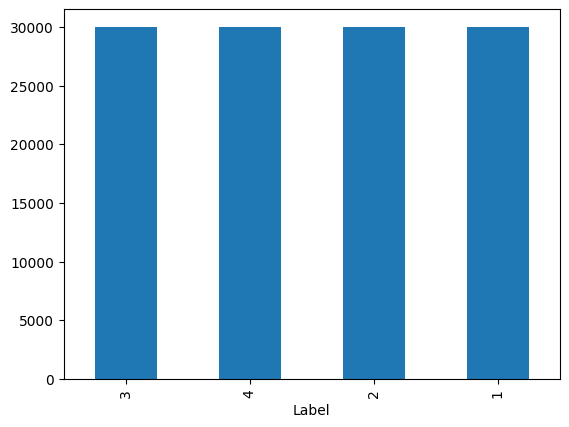

In [3]:
# visualize label distribution
train_en["Label"].value_counts().plot(kind="bar")

The german dataset consits of 9 245 training and 1 028 test samples with rather unbalanced classes

In [4]:
print(train_de.shape)
print(test_de.shape)
train_de.head()

(9245, 2)
(1028, 2)


,Label,Article
0,Sport,21-Jähriger fällt wohl bis Saisonende aus. Wie...
1,Kultur,"Erfundene Bilder zu Filmen, die als verloren g..."
2,Web,Der frischgekürte CEO Sundar Pichai setzt auf ...
3,Wirtschaft,"Putin: ""Einigung, dass wir Menge auf Niveau vo..."
4,Inland,Estland sieht den künftigen österreichischen P...


<Axes: xlabel='Label'>

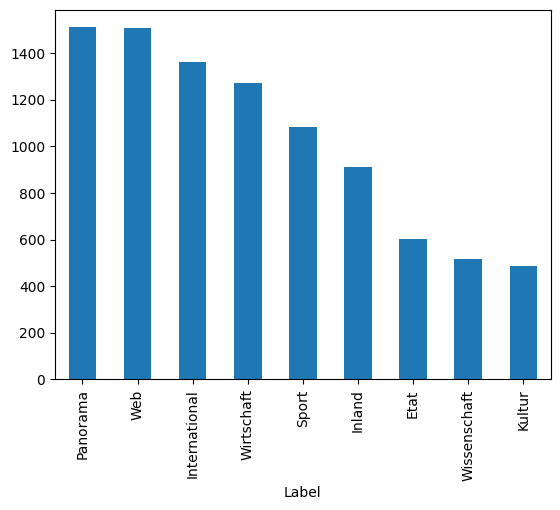

In [5]:
train_de["Label"].value_counts().plot(kind = "bar")

# spaCy

spaCy is a natural language processing library that comes with many built-in features that solve core linguistic tasks.


The following exercises should be carried out by getting familiar with the spaCy API. The documentation can be found at:

https://spacy.io/usage


In [6]:
# spaCy needs a language model to analyze text,
# we will work with both the english and the german language models
# which can be downloaded by executing the following:
# sm -> small model
# lg -> large model
# using the small model is faster, but will be less accurate

!python -m spacy download en_core_web_sm
!python -m spacy download en_core_web_lg

!python -m spacy download de_core_news_sm
!python -m spacy download de_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 111.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 3.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 117.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('d

In [7]:
# imports for spacy
import spacy
import random

import en_core_web_lg
import de_core_news_lg

# load the language models
nlp_en = en_core_web_lg.load()
nlp_de = de_core_news_lg.load()

### Using spaCy and the large model, do the following

* select a news article at random from the english training ds
* Tokenize it & get the lemmatization using spacey
* Print the original article and its tokens/lemmatization
* Repeat for a random article of the german training ds
* What differences do you observe between the tokens and lemmas? Pick out 3 words


In [10]:
# selecting an article
r_en = random.randint(0, train_en.shape[0] - 1)

# ? yourcode here -> tokenization & lemmatization with spacy
docs_en = nlp_en(train_en['Article'][r_en])

print(docs_en.text)
print([token_en.text for token_en in docs_en])
print([token_en.lemma_ for token_en in docs_en])


NEW YORK -- It was supposed to be a tool to help people find stuff on their hard drives. But experts are warning that Google #39;s new search engine for computers may leave a person #39;s personal information at risk if they use shared computers.
['NEW', 'YORK', '--', 'It', 'was', 'supposed', 'to', 'be', 'a', 'tool', 'to', 'help', 'people', 'find', 'stuff', 'on', 'their', 'hard', 'drives', '.', 'But', 'experts', 'are', 'warning', 'that', 'Google', '#', '39;s', 'new', 'search', 'engine', 'for', 'computers', 'may', 'leave', 'a', 'person', '#', '39;s', 'personal', 'information', 'at', 'risk', 'if', 'they', 'use', 'shared', 'computers', '.']
['NEW', 'YORK', '--', 'it', 'be', 'suppose', 'to', 'be', 'a', 'tool', 'to', 'help', 'people', 'find', 'stuff', 'on', 'their', 'hard', 'drive', '.', 'but', 'expert', 'be', 'warn', 'that', 'Google', '#', '39;s', 'new', 'search', 'engine', 'for', 'computer', 'may', 'leave', 'a', 'person', '#', '39;s', 'personal', 'information', 'at', 'risk', 'if', 'they',

In [13]:
# do the same for the german news articles
r_de = random.randint(0, train_de.shape[0] - 1)

# ? yourcode here -> tokenization & lemmatization with spacy
docs_de = nlp_de(train_de['Article'][r_de])

print(docs_de.text)
print([token_de.text for token_de in docs_de])
print([token_de.lemma_ for token_de in docs_de])

Dem einstigen Erdogan-Vertrauten werden Putschpläne vorgeworfen. Istanbul – In Istanbul beginnt am Mittwoch der Prozess gegen den islamischen Prediger Fethullah Gülen, einen früheren Vertrauten und jetzigen Erzfeind von Präsident Recep Tayyip Erdoğan. Der in den USA lebende Gülen soll sich in Abwesenheit wegen Umsturzversuchen und Bildung einer Terrorgruppe verantworten. Mit Gülen sind 70 weitere Verdächtige angeklagt, vor allem ehemalige Polizisten. Gülens Verteidigung hält die Vorwürfe für konstruiert und für einen Beleg der autokratischen Machtansprüche der Staatsführung. Vorwurf: Anweisungen zum Sturz der Regierung Der 74-jährige Gülen war einst ein enger Verbündeter Erdoğans. Die beiden überwarfen sich jedoch vor dem Hintergrund des wachsenden Einflusses des Predigers. Die Regierung warf schließlich Gülens Bewegung vor, hinter den Korruptionsvorwürfen gegen Erdoğans engstes Umfeld zu stecken, die Ende 2013 aufkamen. Die Regierung betrachtet die Bewegung des Geistlichen als eine Ar

### For the articles used above, use spaCy to extract and visualize linguistic features.

* Use spaCy to extract the following attributes for each token:

    * Token, Lemma, Simple POS tag, Detailed POS tag, Syntactic dependency, Word shape, Is alpha, Is stop word


* Print the token attributes or visualize them as a table.

* Explain what each attribute describes.

* Visualize the POS attribute as a dependency plot using spaCy's displacy.

* Repeat the same for the german data set

In [16]:
# ? yourcode here [en]


#for token in docs_en:
  # text, lemma, pos_, tag_, dep_, shape_, is_alpha, is_stop
  #print([token_en.text for token_en in docs_en])

token_df_en = pd.DataFrame({"Text": [token_en.text for token_en in docs_en],
                            "Lemma": [token_en.lemma_ for token_en in docs_en],
                            "POS": [token_en.pos_ for token_en in docs_en],
                            "Tag": [token_en.tag_ for token_en in docs_en],
                            "Dependency": [token_en.dep_ for token_en in docs_en],
                            "Shape": [token_en.shape_ for token_en in docs_en],
                            "Is_Alpha": [token_en.is_alpha for token_en in docs_en],
                            "Is_stop": [token_en.is_stop for token_en in docs_en]
                            })
token_df_en.head()


,Text,Lemma,POS,Tag,Dependency,Shape,Is_Alpha,Is_stop
0,NEW,NEW,PROPN,NNP,compound,XXX,True,False
1,YORK,YORK,PROPN,NNP,ROOT,XXXX,True,False
2,--,--,PUNCT,:,punct,--,False,False
3,It,it,PRON,PRP,nsubjpass,Xx,True,True
4,was,be,AUX,VBD,auxpass,xxx,True,True


In [19]:
import sys
from IPython import display
sys.modules['IPython.core.display'] = display
from spacy import displacy

# displacy visualizes properties of the tokens, such as their dependency, POS tags, etc.

# ? yourcode here [en]
#displacy.serve(docs_en, style="dep")

displacy.render(docs_en, style="dep", jupyter=True)


In [ ]:
# same for the german tokens

# ? your code here [de]

In [ ]:
# ? your code here [de]

### Repeat the same with the small model using the same articles

* What do you observe?

In [22]:
# ? yourcode here [small model, en & de]

import en_core_web_sm

nlp_en_sm = en_core_web_sm.load()

# ? yourcode here -> tokenization & lemmatization with spacy
docs_en_sm = nlp_en_sm(train_en['Article'][r_en])

print(docs_en_sm.text)
print([token_en.text for token_en in docs_en_sm])
print([token_en.lemma_ for token_en in docs_en_sm])
print([token_en.lemma_ for token_en in docs_en])



NEW YORK -- It was supposed to be a tool to help people find stuff on their hard drives. But experts are warning that Google #39;s new search engine for computers may leave a person #39;s personal information at risk if they use shared computers.
['NEW', 'YORK', '--', 'It', 'was', 'supposed', 'to', 'be', 'a', 'tool', 'to', 'help', 'people', 'find', 'stuff', 'on', 'their', 'hard', 'drives', '.', 'But', 'experts', 'are', 'warning', 'that', 'Google', '#', '39;s', 'new', 'search', 'engine', 'for', 'computers', 'may', 'leave', 'a', 'person', '#', '39;s', 'personal', 'information', 'at', 'risk', 'if', 'they', 'use', 'shared', 'computers', '.']
['NEW', 'YORK', '--', 'it', 'be', 'suppose', 'to', 'be', 'a', 'tool', 'to', 'help', 'people', 'find', 'stuff', 'on', 'their', 'hard', 'drive', '.', 'but', 'expert', 'be', 'warn', 'that', 'Google', '#', '39;s', 'new', 'search', 'engine', 'for', 'computer', 'may', 'leave', 'a', 'person', '#', '39;s', 'personal', 'information', 'at', 'risk', 'if', 'they',

### Use spaCy for Named Entity Recognition (NER) of the random Articles

Reminder: Named entities a real-world object, such as a person, location, organization, or product, that can be denoted with a proper name.


Extract named entities for the random English or German article:

* Text: Entity string
* Start: Character start index
* End: Character end index
* Label: Entity type (e.g., PERSON, ORG, DATE)


Visualize the entities as an entity plot with spaCy's displacy

In [30]:
docs_en = nlp_en(train_en["Article"][0])

for ent in docs_en.ents:
  print(ent.text)
  print(ent.start_char)
  print(ent.end_char)
  print(ent.label_)

Reuters
0
7
ORG
Wall Street's dwindling\band
25
53
ORG


In [31]:
displacy.serve(docs_en, style="ent")


Using the 'ent' visualizer
Serving on http://0.0.0.0:5000 ...

Shutting down server on port 5000.


## We can also use spaCy to calculate the similarity between a german and an english article

    Read also: https://spacy.io/usage/spacy-101#vectors-similarity


Using our articles:

* compute the similarity between the english and german article
* Why do you think the sentences "I like fries and burgers" and "Fast food is my favorite food." are so similar?
* Using your own sentences, find two with a similarity above 80%


In [24]:
# what is the similarity between the german and english article? Using .similarity()

docs_en.similarity(docs_de)


0.06500935554504395

In [25]:
# using more similar words belonging to the same "group", achieves a better similarity

fruits = nlp_en("apple banana")
fruits[0].similarity(fruits[1])



0.5831844806671143

In [26]:
# what is the similarity between "I like fries and burgers" and "Fast food is my favorite food."?
sent1 = nlp_en("I like fries and burgers")
sent2 = nlp_en("Fast food is my favorite food.")

sent1.similarity(sent2)


0.7399165034294128

### spaCy also encodes documents and tokens as feature vectors


In [ ]:
token = docs_en[0]
print(token.vector.shape)
print(docs_en.vector.shape)